# 🚲 Bike Demand Prediction

## Project Overview

This project analyzes historical bike-sharing data to understand patterns in bike demand and build a machine learning model to predict rental demand using time and weather information.

### Objectives
- Understand patterns in bike demand.
- Explore relationships between demand, time, and weather.
- Build a baseline regression model.
- Compare it with a non-linear machine learning model.
- Perform feature engineering and error analysis.
- Interpret the final model using feature importance.


## Project Workflow

**Data → EDA → Feature Engineering → Time-Based Split → Modeling → Evaluation → Error Analysis → Interpretation**

Because bike demand is time-dependent, the data is evaluated using a chronological train/test split rather than a random split.


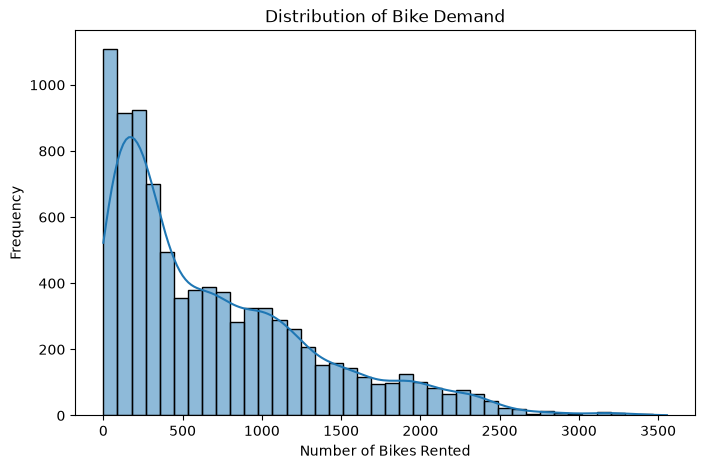

In [114]:
# How is bike demand distributed?
plt.figure(figsize=(8, 5))

sns.histplot(
    df["bike_count"],
    bins=40,
    kde=True
)

plt.title("Distribution of Bike Demand")
plt.xlabel("Number of Bikes Rented")
plt.ylabel("Frequency")

plt.show()

In [115]:
hourly_demand = (
    df.groupby("hour")["bike_count"]
      .mean()
      .sort_values(ascending=False)
)

print(hourly_demand)

hour
18    1502.926027
19    1195.147945
17    1138.509589
20    1068.964384
21    1031.449315
8     1015.701370
16     930.621918
22     922.797260
15     829.186301
14     758.824658
13     733.246575
12     699.441096
23     671.126027
9      645.983562
7      606.005479
11     600.852055
0      541.460274
10     527.821918
1      426.183562
2      301.630137
6      287.564384
3      203.331507
5      139.082192
4      132.591781
Name: bike_count, dtype: float64


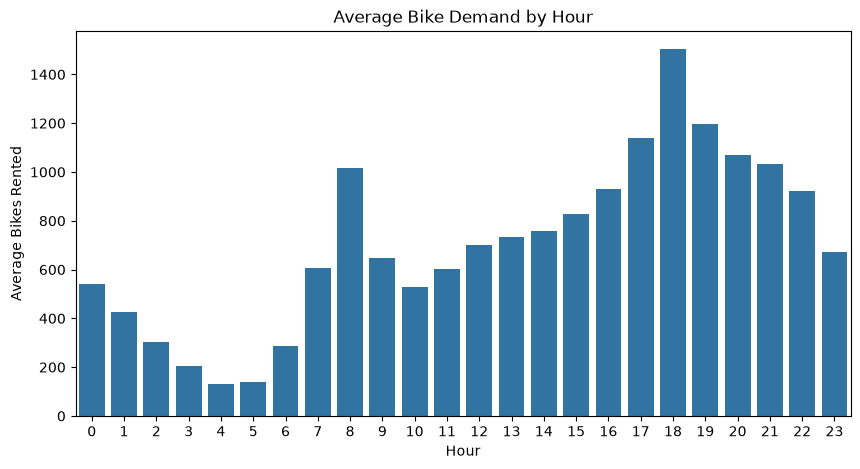

In [116]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=hourly_demand.index,
    y=hourly_demand.values
)

plt.title("Average Bike Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Bikes Rented")

plt.show()

In [117]:
# Compare bike demand across days of the week

day_demand = (
    df.groupby("day_of_week")["bike_count"]
      .mean()
)

print(day_demand)

day_of_week
0    730.563301
1    687.977564
2    740.349359
3    690.704327
4    747.117925
5    709.528846
6    625.155449
Name: bike_count, dtype: float64


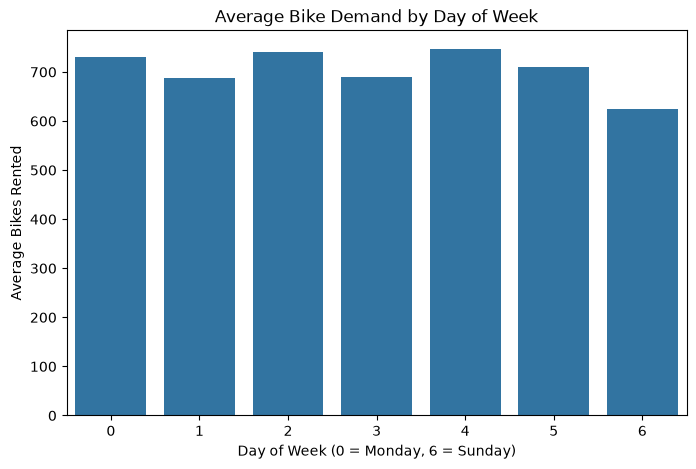

In [118]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=day_demand.index,
    y=day_demand.values
)

plt.title("Average Bike Demand by Day of Week")
plt.xlabel("Day of Week (0 = Monday, 6 = Sunday)")
plt.ylabel("Average Bikes Rented")

plt.show()

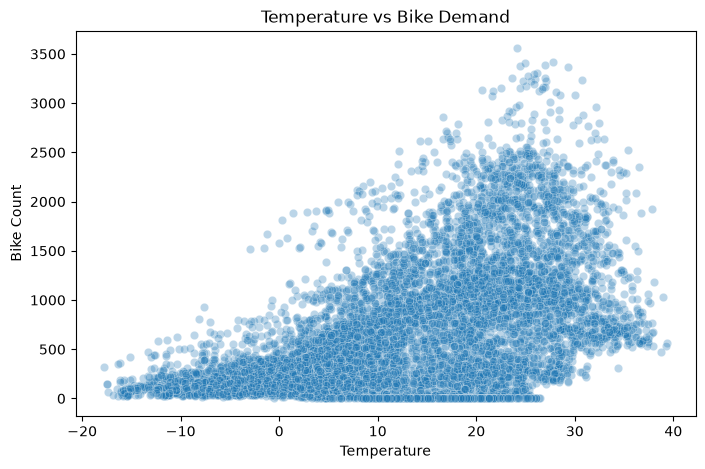

In [119]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="temperature",
    y="bike_count",
    alpha=0.3
)

plt.title("Temperature vs Bike Demand")
plt.xlabel("Temperature")
plt.ylabel("Bike Count")

plt.show()

In [120]:
 # How strongly is each numerical feature related to bike demand?

correlation_with_target = (
    df.corr(numeric_only=True)["bike_count"]
      .sort_values(ascending=False)
)

print(correlation_with_target)

bike_count         1.000000
temperature        0.538558
hour               0.410257
dew_point          0.379788
solar_radiation    0.261837
year               0.215162
visibility         0.199280
month              0.133514
wind_speed         0.121108
day                0.022291
day_of_week       -0.029357
rainfall          -0.123074
snowfall          -0.141804
humidity          -0.199780
Name: bike_count, dtype: float64


In [121]:
# Features = information the model can use
X = df.drop(columns=["bike_count", "date"])

# Target = what we want the model to predict
y = df["bike_count"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (8760, 16)
y shape: (8760,)


## 2. Time-Based Train/Test Split


In [122]:
# Make sure the data is ordered chronologically
df = df.sort_values("date")

# 80% of the data will be used for training
split_index = int(len(df) * 0.8)

# Earlier data → training
X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

# Later data → testing
X_test = X.iloc[split_index:]
y_test = y.iloc[split_index:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("Training period:")
print(df["date"].iloc[0], "to", df["date"].iloc[split_index - 1])

print("\nTesting period:")
print(df["date"].iloc[split_index], "to", df["date"].iloc[-1])

Training data: (7008, 16)
Testing data: (1752, 16)
Training period:
2017-12-01 00:00:00 to 2018-09-18 00:00:00

Testing period:
2018-09-19 00:00:00 to 2018-11-30 00:00:00


In [123]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical columns
numerical_features = [
    "hour",
    "temperature",
    "humidity",
    "wind_speed",
    "visibility",
    "dew_point",
    "solar_radiation",
    "rainfall",
    "snowfall",
    "year",
    "month",
    "day",
    "day_of_week"
]

# Categorical columns
categorical_features = [
    "season",
    "holiday",
    "functioning_day"
]

# Tell sklearn how each type of column should be processed
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [124]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

# Build a complete ML pipeline:
# 1. Preprocess the data
# 2. Train Linear Regression
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

# Learn patterns ONLY from the training data
linear_model.fit(X_train, y_train)

# Predict bike demand for unseen test data
y_pred = linear_model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[436.85874359 526.93265403 585.50289791 597.24945891 626.51950964
 544.05490878 469.53625167 502.23784144 437.61678026 323.72399281]


## 3. Baseline Model — Linear Regression


In [125]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# MAE: average absolute prediction error
mae = mean_absolute_error(y_test, y_pred)

# RMSE: gives extra penalty to large errors
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R²: how much of the variation our model explains
r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Linear Regression Results
-------------------------
MAE : 330.3922105138993
RMSE: 455.0665427180727
R²  : 0.44949903417581305


In [126]:
from sklearn.ensemble import RandomForestRegressor

# Create the complete pipeline
random_forest = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train only on the training data
random_forest.fit(X_train, y_train)

# Predict on unseen test data
rf_pred = random_forest.predict(X_test)

## 4. Random Forest Model


In [127]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_pred)
)

rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("---------------------")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R²  :", rf_r2)

Random Forest Results
---------------------
MAE : 222.19585806697106
RMSE: 319.4335622747364
R²  : 0.7287502407177959


In [128]:
# Create a dataframe to inspect our model's predictions
error_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": rf_pred
})

# Calculate the prediction error
error_df["error"] = (
    error_df["actual"] - error_df["predicted"]
)

# Absolute error tells us how far off we were,
# regardless of whether we overpredicted or underpredicted
error_df["absolute_error"] = (
    error_df["error"].abs()
)

# Show the 10 biggest mistakes
error_df.sort_values(
    "absolute_error",
    ascending=False
).head(10)


,actual,predicted,error,absolute_error
854,2108,711.793333,1396.206667,1396.206667
692,2202,842.500000,1359.500000,1359.500000
1143,1975,617.543333,1357.456667,1357.456667
1398,1956,634.116667,1321.883333,1321.883333
1365,1916,629.236667,1286.763333,1286.763333
126,1237,2497.973333,-1260.973333,1260.973333
1068,1906,671.166667,1234.833333,1234.833333
994,2074,848.113333,1225.886667,1225.886667
159,440,1642.650000,-1202.650000,1202.650000
1475,1904,707.326667,1196.673333,1196.673333


In [129]:
# Copy the test features
error_analysis = X_test.copy()

# Add the actual bike demand
error_analysis["actual"] = y_test.values

# Add our model's prediction
error_analysis["predicted"] = rf_pred

# Calculate how far the prediction was from reality
error_analysis["absolute_error"] = (
    error_analysis["actual"]
    - error_analysis["predicted"]
).abs()

# Show the biggest mistakes
error_analysis.sort_values(
    "absolute_error",
    ascending=False
).head(10)

,hour,temperature,humidity,wind_speed,visibility,dew_point,solar_radiation,rainfall,snowfall,season,holiday,functioning_day,year,month,day,day_of_week,actual,predicted,absolute_error
7856,8,8.1,85,1.2,772,5.7,0.26,0.0,0.0,Autumn,No Holiday,Yes,2018,10,24,2,2108,711.793333,1396.206667
7688,8,9.2,68,0.2,952,3.5,0.28,0.0,0.0,Autumn,No Holiday,Yes,2018,10,17,2,2202,842.500000,1359.500000
8144,8,7.2,80,0.8,515,3.9,0.13,0.0,0.0,Autumn,No Holiday,Yes,2018,11,5,0,1975,617.543333,1357.456667
8418,18,9.9,74,2.6,492,5.4,0.00,0.0,0.0,Autumn,No Holiday,Yes,2018,11,16,4,1956,634.116667,1321.883333
8360,8,5.0,77,1.5,1115,1.2,0.07,0.0,0.0,Autumn,No Holiday,Yes,2018,11,14,2,1916,629.236667,1286.763333
7146,18,20.3,35,2.4,2000,4.3,0.46,0.0,0.0,Autumn,Holiday,Yes,2018,9,24,0,1237,2497.973333,1260.973333
8072,8,4.7,72,1.0,1306,0.0,0.12,0.0,0.0,Autumn,No Holiday,Yes,2018,11,2,4,1906,671.166667,1234.833333
8010,18,8.4,52,2.6,2000,-0.9,0.03,0.0,0.0,Autumn,No Holiday,Yes,2018,10,30,1,2074,848.113333,1225.886667
7160,8,12.0,61,1.3,1988,4.6,0.60,0.0,0.0,Autumn,Holiday,Yes,2018,9,25,1,440,1642.650000,1202.650000
8490,18,7.5,48,2.4,1079,-2.8,0.00,0.0,0.0,Autumn,No Holiday,Yes,2018,11,19,0,1904,707.326667,1196.673333


## 5. Error Analysis


In [130]:
hour_errors = (
    error_analysis
    .groupby("hour")["absolute_error"]
    .mean()
    .sort_values(ascending=False)
)

print(hour_errors)

hour
8     655.288630
18    564.533470
7     362.375799
19    329.384886
21    287.282283
22    283.339726
9     276.329178
20    264.714566
0     230.244247
17    201.940228
23    197.696530
1     184.972648
16    177.049817
12    159.648995
15    156.754292
11    146.172648
14    140.355753
10    138.388539
13    137.042329
6     128.620731
2     126.149817
3      83.933151
4      50.318767
5      50.163562
Name: absolute_error, dtype: float64


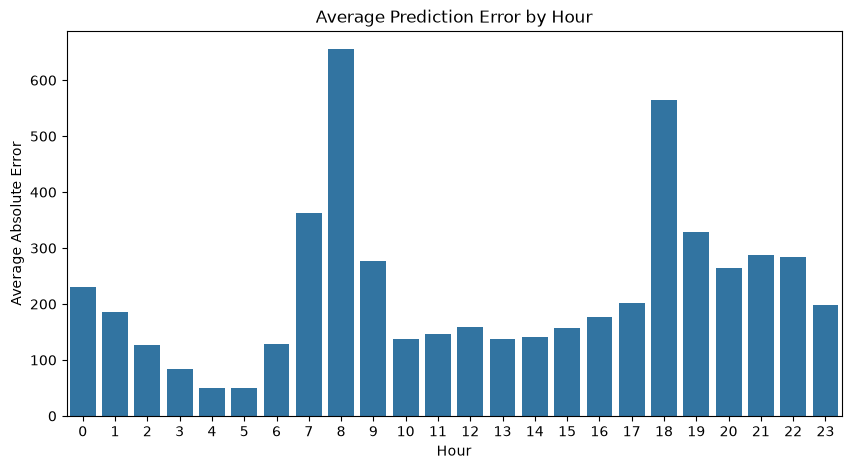

In [131]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=hour_errors.index,
    y=hour_errors.values
)

plt.title("Average Prediction Error by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Absolute Error")

plt.show()

In [132]:
# Average actual and predicted demand for each hour

hour_comparison = (
    error_analysis
    .groupby("hour")[["actual", "predicted"]]
    .mean()
)

print(hour_comparison)

           actual    predicted
hour                          
0      565.013699   487.084612
1      442.191781   389.721416
2      304.205479   271.124247
3      207.520548   178.272420
4      133.972603   123.627808
5      126.794521   124.436986
6      273.630137   236.075982
7      624.712329   499.312877
8     1101.630137   695.619863
9      698.369863   539.767991
10     591.232877   571.367443
11     664.958904   645.014749
12     781.410959   741.125890
13     850.753425   823.437123
14     911.219178   901.040502
15    1004.013699   978.130091
16    1111.054795  1068.087991
17    1316.986301  1210.167808
18    1627.616438  1223.747900
19    1216.301370   979.927260
20    1044.000000   902.455388
21     993.767123   825.022922
22     910.109589   751.300000
23     666.465753   604.056438


## 10. Final Prediction Analysis


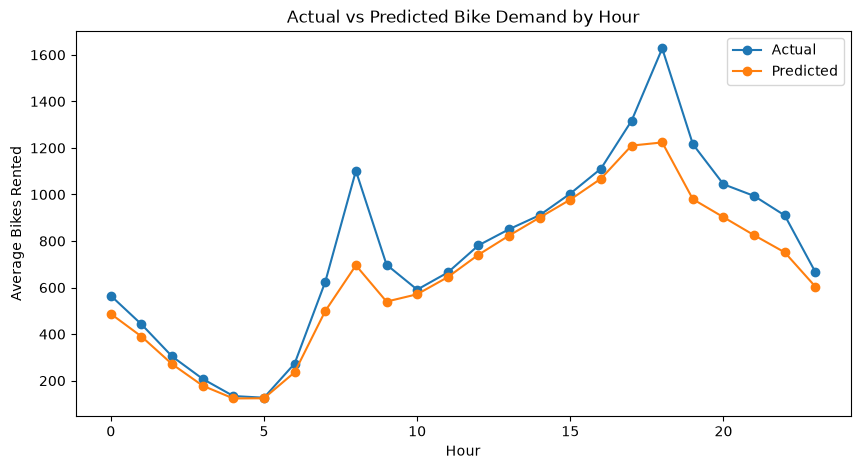

In [133]:
plt.figure(figsize=(10, 5))

plt.plot(
    hour_comparison.index,
    hour_comparison["actual"],
    marker="o",
    label="Actual"
)

plt.plot(
    hour_comparison.index,
    hour_comparison["predicted"],
    marker="o",
    label="Predicted"
)

plt.title("Actual vs Predicted Bike Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Bikes Rented")

plt.legend()

plt.show()

## 6. Seasonal Error Check


season
Autumn    222.195858
Name: absolute_error, dtype: float64


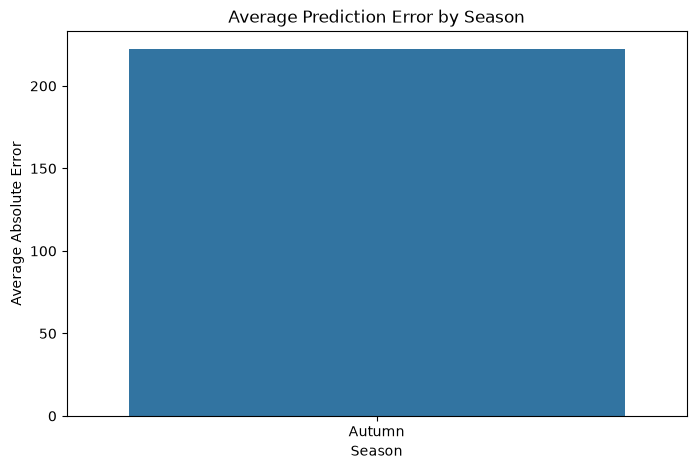

In [135]:
season_errors = (
    error_analysis
    .groupby("season")["absolute_error"]
    .mean()
    .sort_values(ascending=False)
)

print(season_errors)
plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_errors.index,
    y=season_errors.values
)

plt.title("Average Prediction Error by Season")
plt.xlabel("Season")
plt.ylabel("Average Absolute Error")

plt.show()

## 7. Feature Engineering — Rush Hour


In [136]:
# Create a rush-hour feature
df["is_rush_hour"] = df["hour"].isin(
    [7, 8, 9, 17, 18, 19]
).astype(int)

# Check the result
df[["hour", "is_rush_hour"]].drop_duplicates().sort_values("hour")

,hour,is_rush_hour
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0
5,5,0
6,6,0
7,7,1
8,8,1
9,9,1


In [137]:
# Add the new feature to training and testing data
X_train_fe = X_train.copy()
X_test_fe = X_test.copy()

X_train_fe["is_rush_hour"] = X_train_fe["hour"].isin(
    [7, 8, 9, 17, 18, 19]
).astype(int)

X_test_fe["is_rush_hour"] = X_test_fe["hour"].isin(
    [7, 8, 9, 17, 18, 19]
).astype(int)


# Automatically identify numerical and categorical columns
numeric_features_fe = X_train_fe.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features_fe = X_train_fe.select_dtypes(
    exclude=np.number
).columns.tolist()


# Build a new preprocessor
preprocessor_fe = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features_fe
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_fe
        )
    ]
)


# Random Forest with the new feature
rf_feature_engineered = Pipeline(
    steps=[
        ("preprocessor", preprocessor_fe),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


# Train
rf_feature_engineered.fit(
    X_train_fe,
    y_train
)


# Predict
rf_fe_pred = rf_feature_engineered.predict(
    X_test_fe
)

## 8. Feature-Engineered Model


In [138]:
# Evaluate the new model

fe_mae = mean_absolute_error(
    y_test,
    rf_fe_pred
)

fe_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_fe_pred
    )
)

fe_r2 = r2_score(
    y_test,
    rf_fe_pred
)

print("Random Forest + Rush Hour Feature")
print("----------------------------------")
print("MAE :", fe_mae)
print("RMSE:", fe_rmse)
print("R²  :", fe_r2)

Random Forest + Rush Hour Feature
----------------------------------
MAE : 222.32872146118723
RMSE: 315.22060398030175
R²  : 0.7358579976460696


## 9. Feature Importance


In [139]:
# Get the trained Random Forest model
rf_model = rf_feature_engineered.named_steps["model"]

# Get feature names after preprocessing
feature_names = (
    rf_feature_engineered
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Create a table of feature importance
feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_model.feature_importances_
})

# Show the most important features
feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
)

feature_importance.head(15)

,feature,importance
1,num__temperature,0.381463
0,num__hour,0.265056
6,num__solar_radiation,0.080334
2,num__humidity,0.069023
7,num__rainfall,0.043077
12,num__day_of_week,0.035571
5,num__dew_point,0.025632
13,num__is_rush_hour,0.023684
10,num__month,0.014042
21,cat__functioning_day_Yes,0.013533


In [140]:
# Add prediction error to our test data

final_analysis = X_test_fe.copy()

final_analysis["actual"] = y_test.values
final_analysis["predicted"] = rf_fe_pred

final_analysis["error"] = (
    final_analysis["actual"]
    - final_analysis["predicted"]
)

final_analysis["absolute_error"] = (
    final_analysis["error"].abs()
)

final_analysis.head()

,hour,temperature,humidity,wind_speed,visibility,dew_point,solar_radiation,rainfall,snowfall,season,...,functioning_day,year,month,day,day_of_week,is_rush_hour,actual,predicted,error,absolute_error
7021,13,26.5,39,1.7,1560,11.4,2.15,0.0,0.0,Autumn,...,No,2018,9,19,2,0,0,7.816667,-7.816667,7.816667
7022,14,26.1,40,1.2,1840,11.4,1.21,0.0,0.0,Autumn,...,No,2018,9,19,2,0,0,6.823333,-6.823333,6.823333
7023,15,25.9,39,1.4,1836,10.8,0.90,0.0,0.0,Autumn,...,No,2018,9,19,2,0,0,19.093333,-19.093333,19.093333
7024,16,25.6,41,1.2,1594,11.3,0.65,0.0,0.0,Autumn,...,No,2018,9,19,2,0,0,265.510000,-265.510000,265.510000
7025,17,25.0,44,1.3,1883,11.8,0.36,0.0,0.0,Autumn,...,No,2018,9,19,2,1,0,275.680000,-275.680000,275.680000


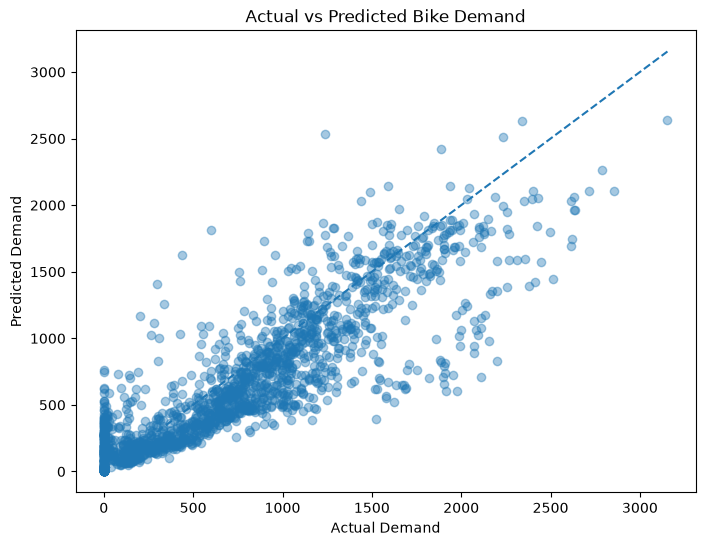

In [141]:
plt.figure(figsize=(8, 6))

plt.scatter(
    final_analysis["actual"],
    final_analysis["predicted"],
    alpha=0.4
)

# Perfect prediction line
plt.plot(
    [final_analysis["actual"].min(),
     final_analysis["actual"].max()],
    [final_analysis["actual"].min(),
     final_analysis["actual"].max()],
    linestyle="--"
)

plt.title("Actual vs Predicted Bike Demand")
plt.xlabel("Actual Demand")
plt.ylabel("Predicted Demand")

plt.show()

# Conclusion

This project investigated whether historical time and weather information could be used to predict bike rental demand.

Exploratory analysis showed that demand varies substantially throughout the day, with strong increases during peak hours. Weather-related variables also showed meaningful relationships with bike demand.

A Linear Regression model was first used as a baseline and achieved an R² of approximately **0.45**.

A Random Forest model performed substantially better, achieving:

* **MAE:** ~222 bikes
* **RMSE:** ~319 bikes
* **R²:** ~0.73

Feature engineering with a `is_rush_hour` variable produced a small additional improvement:

* **MAE:** ~222 bikes
* **RMSE:** ~315 bikes
* **R²:** ~0.736

Feature importance analysis showed that **temperature and hour** were the two strongest contributors to the Random Forest's predictions, followed by solar radiation and humidity.

### Error Analysis

The model performed reasonably well for low and moderate demand levels but struggled with extreme demand spikes.

For observations where actual demand was at least 1,500 bikes, the model had an average error of approximately **+388 bikes**, meaning it systematically underpredicted high-demand periods.

This suggests that while the model captures the overall demand pattern, extreme peaks remain difficult to predict accurately.

### Key Takeaways

1. Time of day is an important signal for bike demand.
2. Weather variables provide substantial predictive information.
3. Random Forest captured non-linear relationships better than Linear Regression.
4. Feature engineering provided a modest improvement.
5. The main remaining weakness is underprediction during extreme demand peaks.

Overall, the project demonstrates a complete machine learning workflow from exploratory analysis to model evaluation and error analysis, while also showing why evaluating a model requires more than looking at a single performance metric.


## 11. High-Demand Error Analysis


In [142]:
# How much does the model over/under-predict?

high_demand = final_analysis[
    final_analysis["actual"] >= 1500
]

print("High-demand observations:", len(high_demand))

print(
    "Average error:",
    high_demand["error"].mean()
)

print(
    "Average absolute error:",
    high_demand["absolute_error"].mean()
)

High-demand observations: 233
Average error: 388.4301716738197
Average absolute error: 436.2766094420601


# 12. Final Findings & Conclusion

The analysis shows that bike demand varies strongly by time of day and is also closely associated with weather-related variables.

Linear Regression provided a baseline R² of approximately **0.45**. Random Forest substantially improved performance, reaching an R² of approximately **0.73**. Adding a `is_rush_hour` feature produced a small additional improvement, with the final model reaching an R² of approximately **0.736**, MAE of approximately **222 bikes**, and RMSE of approximately **315 bikes**.

Feature importance analysis identified **temperature** and **hour** as the strongest contributors to the Random Forest predictions, followed by solar radiation and humidity.

Error analysis showed that the model performs better for low and moderate demand levels but tends to underpredict extreme demand spikes. For the 233 test observations with actual demand of at least 1,500 bikes, the average error was approximately **+388 bikes**, indicating systematic underprediction in this high-demand group.

### Key Takeaways
1. Time of day is an important signal for bike demand.
2. Weather variables provide substantial predictive information.
3. Random Forest captures non-linear relationships better than Linear Regression.
4. Rush-hour feature engineering provides a modest improvement.
5. Extreme demand peaks remain the main weakness of the final model.

### Future Improvements
- Add richer time-based features.
- Explore lag and rolling-demand features where appropriate.
- Incorporate holiday and event information.
- Tune Random Forest hyperparameters and compare additional models.
- Investigate methods specifically suited to demand forecasting.
